# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from scipy.stats import gaussian_kde

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
file_path = "../1.DATASET/cmi_internet.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


# Age

In [ ]:
age_counts = df["Basic_Demos-Age"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# CGAS Scores

In [ ]:

score_counts = df["CGAS-CGAS_Score"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of CGAS Scores")
plt.xlim(20, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# Physical attributes

## general overview

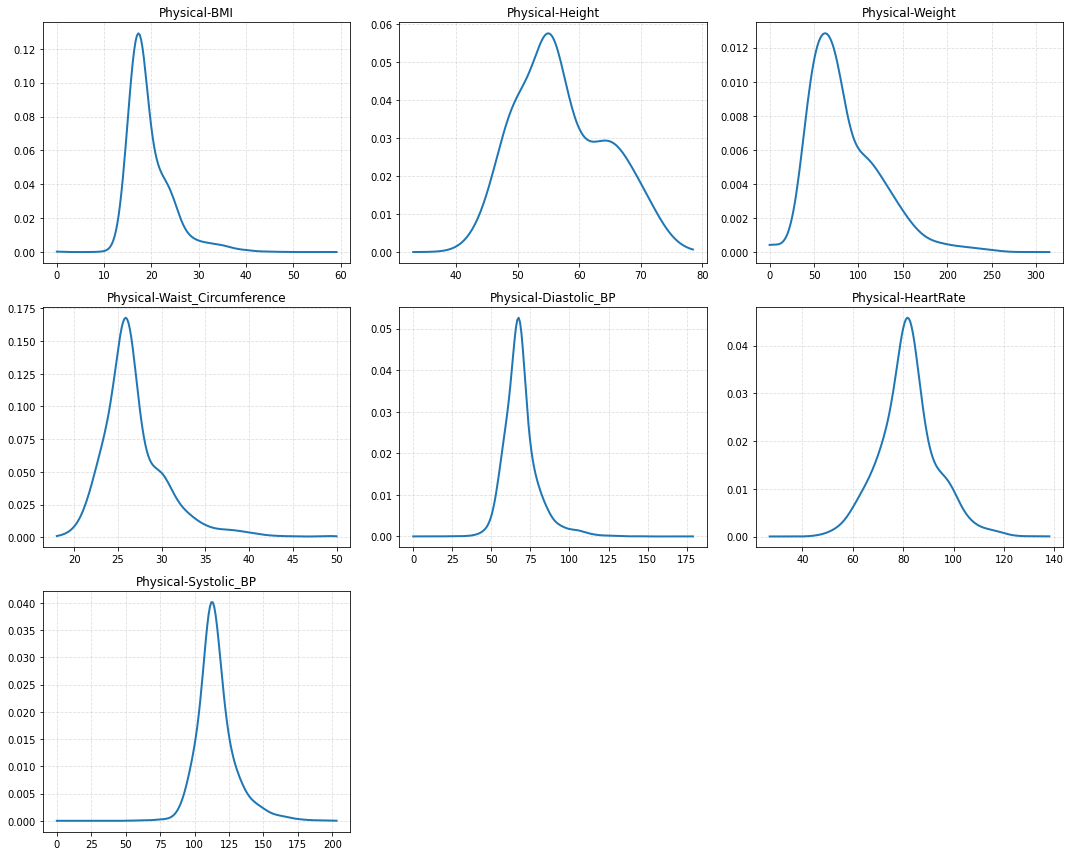

In [3]:
cols = [
    'Physical-BMI',
    'Physical-Height',
    'Physical-Weight',
    'Physical-Waist_Circumference',
    'Physical-Diastolic_BP',
    'Physical-HeartRate',
    'Physical-Systolic_BP'
]

fig, ax = plt.subplots(3, 3, figsize=(15, 12))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(data.min(), data.max(), 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].grid(True, linestyle='--', alpha=0.4)

# rimuove i subplot vuoti (perché 9 spazi ma 7 variabili)
for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

#from this I would say:
#physical height: we drop
# weight: has a similar shape to waist circumference, so drop weight and keep circumference
#diastolic and systolic have the same shape, so we can do something 
#heartrate: keep

## Weight vs Height

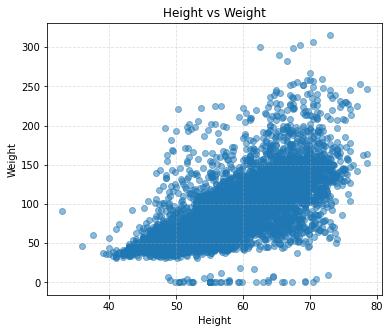

In [4]:
x = df["Physical-Height"]
y = df["Physical-Weight"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.5)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

## Systolic and diastolic

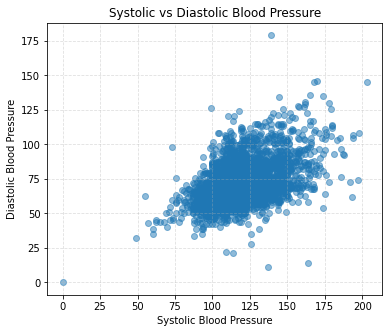

In [5]:

x = df["Physical-Systolic_BP"]
y = df["Physical-Diastolic_BP"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.5)

plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Diastolic Blood Pressure")
plt.title("Systolic vs Diastolic Blood Pressure")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

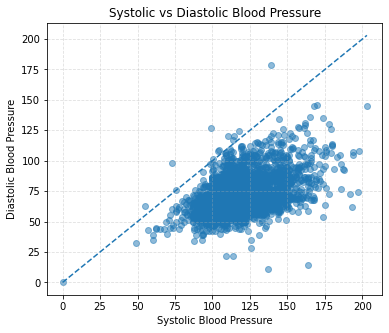

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(x, y, alpha=0.5)

# linea y = x
vals = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()))
plt.plot(vals, vals, linestyle="--")

plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Diastolic Blood Pressure")
plt.title("Systolic vs Diastolic Blood Pressure")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## "Heart" variables vs Weight

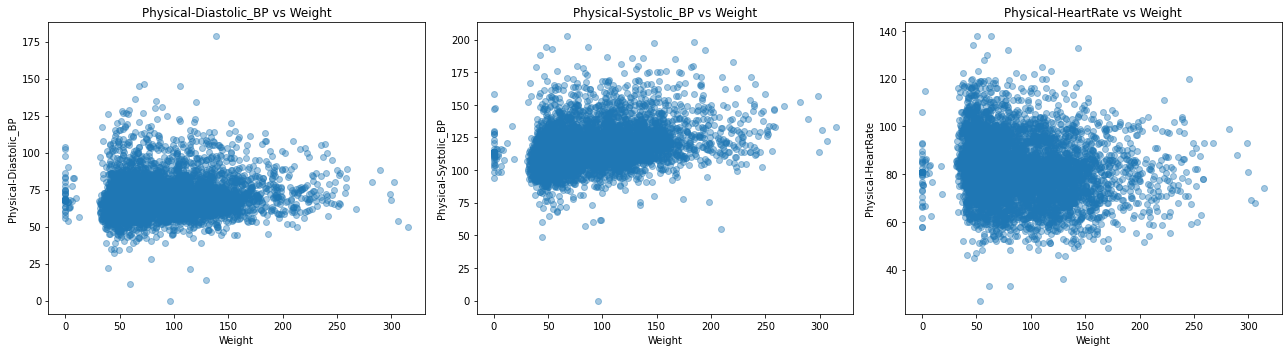

In [14]:
cols = [
    "Physical-Diastolic_BP",
    "Physical-Systolic_BP",
    "Physical-HeartRate"
]

fig, ax = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(cols):

    ax[i].scatter(
        df["Physical-Weight"],
        df[col],
        alpha=0.4
    )

    ax[i].set_xlabel("Weight")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} vs Weight")

plt.tight_layout()
plt.show()

## "Heart" variables vs Age

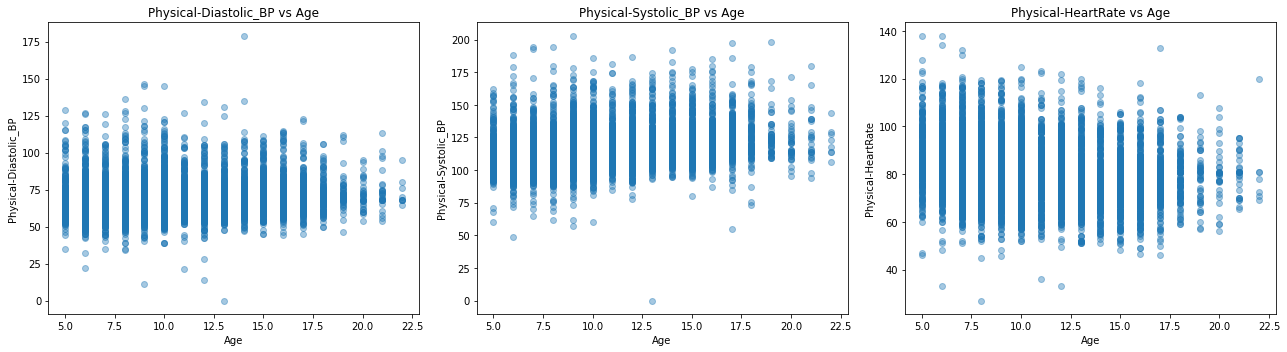

In [15]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(cols):

    ax[i].scatter(
        df["Basic_Demos-Age"],
        df[col],
        alpha=0.4
    )

    ax[i].set_xlabel("Age")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} vs Age")

plt.tight_layout()
plt.show()

## Height, Weight, BMI vs Age

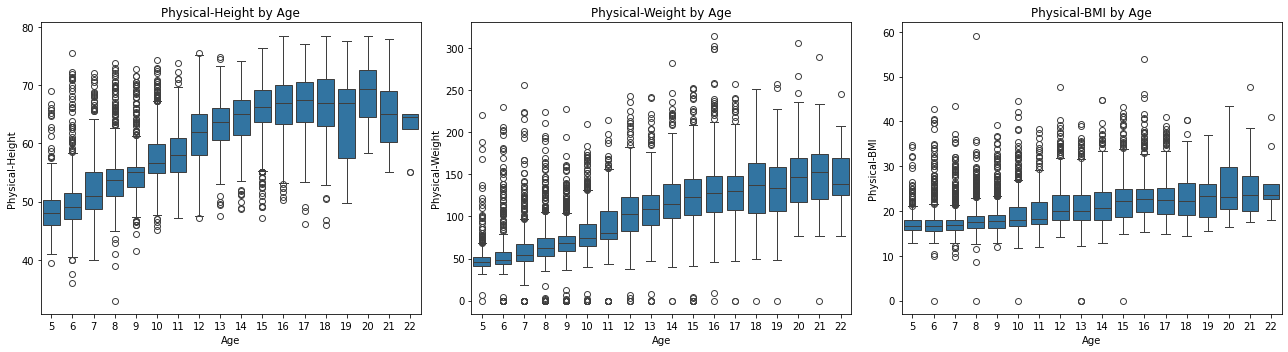

In [9]:
cols = [
    "Physical-Height",
    "Physical-Weight",
    "Physical-BMI"
]

fig, ax = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(cols):

    sns.boxplot(
        x=df["Basic_Demos-Age"],
        y=df[col],
        ax=ax[i]
    )

    ax[i].set_xlabel("Age")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} by Age")

plt.tight_layout()
plt.show()

## Weight, Height, Age vs Waist Circumference

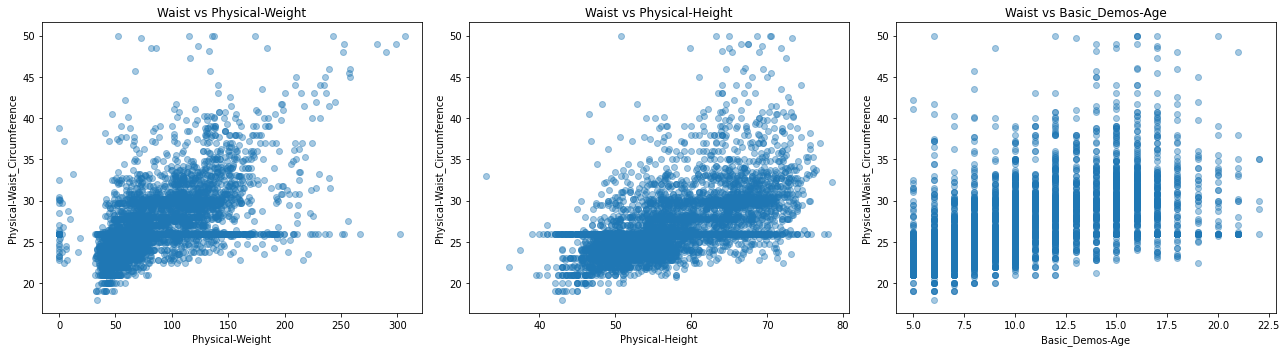

In [10]:
cols = [
    "Physical-Weight",
    "Physical-Height",
    "Basic_Demos-Age"
]

fig, ax = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(cols):

    ax[i].scatter(
        df[col],
        df["Physical-Waist_Circumference"],
        alpha=0.4
    )

    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Physical-Waist_Circumference")
    ax[i].set_title(f"Waist vs {col}")

plt.tight_layout()
plt.show()

In [13]:
df["Physical-Waist_Circumference"].value_counts()

Physical-Waist_Circumference
26.00    1633
25.75     182
23.75     173
27.75     159
29.75     128
         ... 
18.00       1
38.10       1
42.25       1
39.50       1
20.75       1
Name: count, Length: 129, dtype: int64

# Max Stage vs time

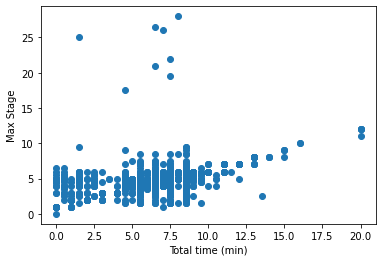

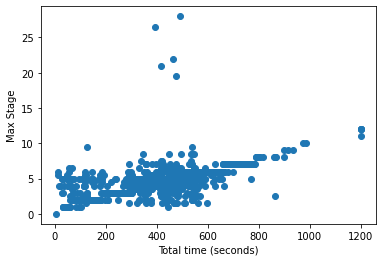

In [11]:
# this shows that the stage does not depend only on the time.
# probably we should keep the max stage bc it's more informative, since that for the same time we can have different stages

df["Fitness_Endurance_Time_Total"] = (
    df["Fitness_Endurance-Time_Mins"]*60 +
    df["Fitness_Endurance-Time_Sec"]
)

#some values disappear bc of missing values.

plt.scatter(df["Fitness_Endurance-Time_Mins"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (min)")
plt.ylabel("Max Stage")
plt.show()

plt.scatter(df["Fitness_Endurance_Time_Total"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (seconds)")
plt.ylabel("Max Stage")
plt.show()

# FGC vs Zone

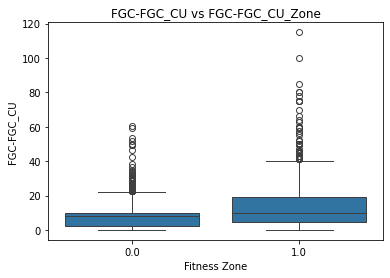

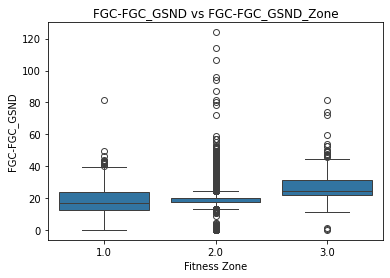

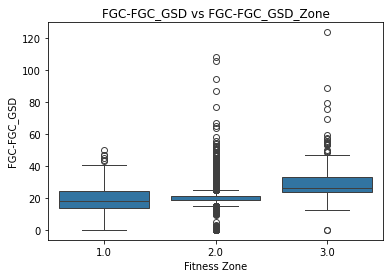

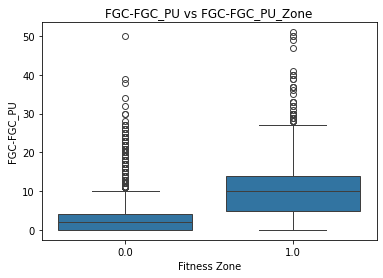

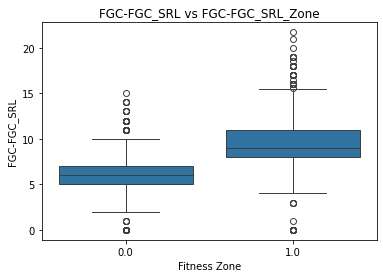

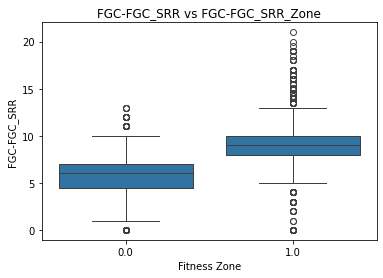

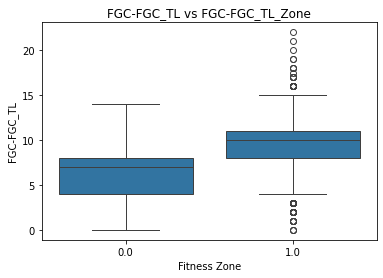

In [12]:
# also here the score got in FGCs is not the only factor that determines the "fitness zone", since the margins of the zone overlap
# this time FGCs are more informative 
tests = [
    ("FGC-FGC_CU","FGC-FGC_CU_Zone"),
    ("FGC-FGC_GSND","FGC-FGC_GSND_Zone"),
    ("FGC-FGC_GSD","FGC-FGC_GSD_Zone"),
    ("FGC-FGC_PU","FGC-FGC_PU_Zone"),
    ("FGC-FGC_SRL","FGC-FGC_SRL_Zone"),
    ("FGC-FGC_SRR","FGC-FGC_SRR_Zone"),
    ("FGC-FGC_TL","FGC-FGC_TL_Zone")
]

for score, zone in tests:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[zone], y=df[score])
    
    plt.xlabel("Fitness Zone")
    plt.ylabel(score)
    plt.title(f"{score} vs {zone}")
    
    plt.show()